# Week 3 — Aido Rover Feature Importance Analysis

This notebook analyzes which telemetry features contribute most strongly to Aido Rover operational mode classification.

Feature importance is evaluated using two complementary methods:

- Random Forest impurity-based feature importance
- Permutation importance on the held-out test set

The analysis also focuses specifically on distinguishing FAULT from PATROL to identify operational signals that may be useful for Rover fleet monitoring.

## 1. Setup and Data Preparation

Import the required libraries and reconstruct the feature engineering and train/test split used in the Week 3 classification model.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score
from sklearn.metrics import make_scorer

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

### Load Synthetic Rover Telemetry

The Week 2 synthetic telemetry dataset is loaded and prepared using the same feature engineering process as the classification notebook.

In [2]:
df = pd.read_csv("../Data/aido_rover_telemetry.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values(
    ["rover_id", "timestamp"]
).reset_index(drop=True)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (181440, 20)


,rover_id,timestamp,operational_mode,latitude,longitude,lidar_distance_m,wheel_torque_fl,wheel_torque_fr,wheel_torque_rl,wheel_torque_rr,imu_accel_x,imu_accel_y,imu_accel_z,ambient_temperature_c,battery_soc,task_success,gps_dropout_flag,lidar_saturation_flag,battery_drop_flag,sensor_noise_flag
0,AIDO_001,2026-07-01 00:00:00,PATROL,1.354202,103.821034,13.699527,15.488216,17.496137,18.483317,16.461332,0.027548,0.065830,9.635538,22.987241,76.428284,1,0,0,0,0
1,AIDO_001,2026-07-01 00:05:00,FAULT,1.354486,103.820582,0.486087,5.560991,19.340842,4.025754,12.218663,-0.209815,-0.043348,9.601425,21.239938,76.275079,1,0,0,0,0
2,AIDO_001,2026-07-01 00:10:00,ALERT,1.354647,103.820291,0.976473,35.108406,21.019085,15.790379,27.107367,-0.009860,-0.163633,9.721586,21.241867,76.155109,1,0,0,0,0
3,AIDO_001,2026-07-01 00:15:00,PATROL,1.353859,103.821427,6.150354,22.704654,16.397383,12.056365,20.362447,0.554334,-0.029707,9.735898,21.616087,76.014695,1,0,0,0,0
4,AIDO_001,2026-07-01 00:20:00,PATROL,1.354567,103.820920,12.263115,24.153797,10.759237,13.542237,20.654680,-0.063300,-0.234918,10.039323,21.213952,75.885342,1,0,0,0,0


### Recreate Engineered Features

The same engineered features used in the classification model are recreated to ensure that feature importance is evaluated on an identical predictor set.

In [3]:
df["battery_soc_roll_mean"] = (
    df.groupby("rover_id")["battery_soc"]
      .transform(lambda x: x.rolling(window=10, min_periods=1).mean())
)

df["battery_soc_roll_std"] = (
    df.groupby("rover_id")["battery_soc"]
      .transform(lambda x: x.rolling(window=10, min_periods=2).std())
)

In [4]:
df["imu_magnitude"] = np.sqrt(
    df["imu_accel_x"] ** 2
    + df["imu_accel_y"] ** 2
    + df["imu_accel_z"] ** 2
)

In [5]:
wheel_cols = [
    "wheel_torque_fl",
    "wheel_torque_fr",
    "wheel_torque_rl",
    "wheel_torque_rr"
]

df["wheel_imbalance"] = df[wheel_cols].std(axis=1)

In [6]:
df["prev_latitude"] = df.groupby("rover_id")["latitude"].shift(1)
df["prev_longitude"] = df.groupby("rover_id")["longitude"].shift(1)
df["prev_timestamp"] = df.groupby("rover_id")["timestamp"].shift(1)

In [7]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371000

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arctan2(
        np.sqrt(a),
        np.sqrt(1 - a)
    )

    return R * c


df["gps_distance_m"] = haversine_distance(
    df["prev_latitude"],
    df["prev_longitude"],
    df["latitude"],
    df["longitude"]
)

df["time_diff_seconds"] = (
    df["timestamp"] - df["prev_timestamp"]
).dt.total_seconds()

df["gps_speed_mps"] = (
    df["gps_distance_m"] / df["time_diff_seconds"]
)

### Define Model Features

The same raw and engineered telemetry features used in the classification notebook are selected to reproduce the Random Forest model.

In [9]:
feature_columns = [
    "battery_soc",
    "lidar_distance_m",
    "wheel_torque_fl",
    "wheel_torque_fr",
    "wheel_torque_rl",
    "wheel_torque_rr",
    "imu_accel_x",
    "imu_accel_y",
    "imu_accel_z",
    "ambient_temperature_c",
    "battery_soc_roll_mean",
    "battery_soc_roll_std",
    "imu_magnitude",
    "wheel_imbalance",
    "gps_speed_mps"
]

X = df[feature_columns].copy()
y = df["operational_mode"].copy()

print("Number of features:", len(feature_columns))
print("X shape:", X.shape)

Number of features: 15
X shape: (181440, 15)


### Reproduce Train/Test Split

The same 80/20 stratified split and random seed used in the classification notebook are applied so that feature importance is calculated for the same modeling setup.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_SEED
)

train_medians = X_train.median()

X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("Training missing values:", X_train.isna().sum().sum())
print("Test missing values:", X_test.isna().sum().sum())

Training set: (145152, 15)
Test set: (36288, 15)
Training missing values: 0
Test missing values: 0


### Refit Random Forest

The Random Forest configuration from the classification notebook is reproduced before calculating feature importance.

In [11]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = rf_model.score(X_test, y_test)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    average="macro"
)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"Random Forest Macro-F1: {rf_f1:.4f}")

Random Forest Accuracy: 0.9672
Random Forest Macro-F1: 0.9327


## 2. Impurity-Based Feature Importance

Random Forest impurity-based importance measures how much each feature contributes to reducing classification impurity across the decision trees.

Higher importance indicates that a feature is used more strongly by the forest when separating operational modes.

In [12]:
impurity_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
})

impurity_importance = impurity_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(impurity_importance)

,Feature,Importance
0,wheel_torque_fr,0.189296
1,wheel_torque_rl,0.171105
2,wheel_torque_fl,0.167396
3,wheel_torque_rr,0.163656
4,lidar_distance_m,0.117417
5,wheel_imbalance,0.109390
6,imu_magnitude,0.010487
7,imu_accel_y,0.010108
8,imu_accel_x,0.009853
9,imu_accel_z,0.008969


### Impurity-Based Feature Importance Ranking

The feature importance scores are ranked to identify which telemetry variables contribute most strongly to the Random Forest classification decisions.

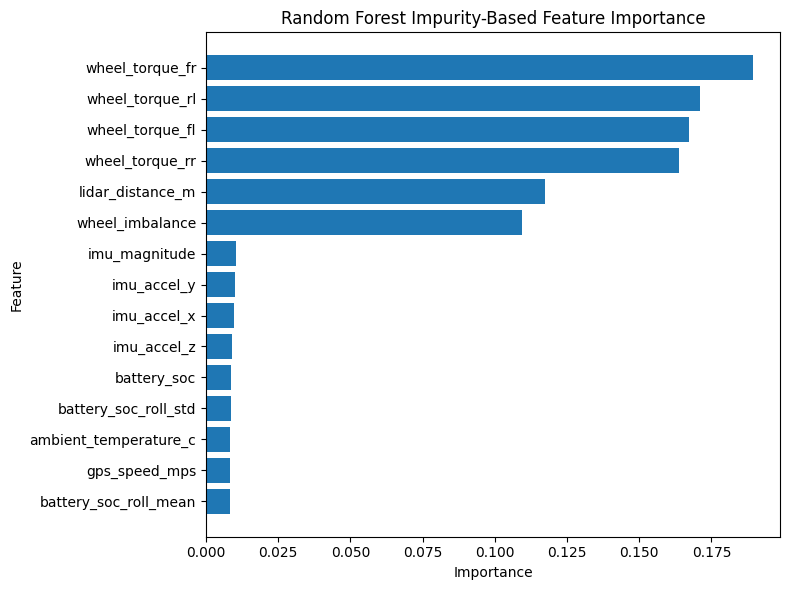

In [13]:
plot_data = impurity_importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(8, 6))

plt.barh(
    plot_data["Feature"],
    plot_data["Importance"]
)

plt.title("Random Forest Impurity-Based Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

**Interpretation:**  
The impurity-based ranking is dominated by wheel torque measurements, with all four individual wheel torque features receiving the highest importance scores. LiDAR distance and the engineered wheel imbalance score also contribute substantially, while battery, IMU, temperature, and GPS-derived features receive relatively low impurity importance. This suggests that wheel-related telemetry plays a major role in the Random Forest's operational mode classification. However, impurity-based importance can distribute importance across correlated predictors, so permutation importance is evaluated next as a complementary measure.

## 3. Permutation Importance

Permutation importance measures how much model performance decreases when the values of one feature are randomly shuffled while all other features remain unchanged.

A larger decrease in macro-F1 indicates that the model relies more strongly on that feature for accurate classification.

In [14]:
perm_result = permutation_importance(
    rf_model,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=5,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

In [15]:
perm_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": perm_result.importances_mean,
    "Std": perm_result.importances_std
})

perm_importance = perm_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(perm_importance)

,Feature,Importance,Std
0,wheel_imbalance,0.295773,0.001583
1,wheel_torque_fr,0.201280,0.000896
2,wheel_torque_fl,0.191880,0.001441
3,wheel_torque_rr,0.191126,0.000690
4,wheel_torque_rl,0.189023,0.000818
5,lidar_distance_m,0.151482,0.001640
6,battery_soc,0.001157,0.000452
7,imu_magnitude,0.000362,0.000178
8,imu_accel_z,0.000350,0.000271
9,ambient_temperature_c,0.000344,0.000295


### Permutation Feature Importance Ranking

Permutation importance ranks features according to the decrease in held-out macro-F1 caused by randomly shuffling each predictor.

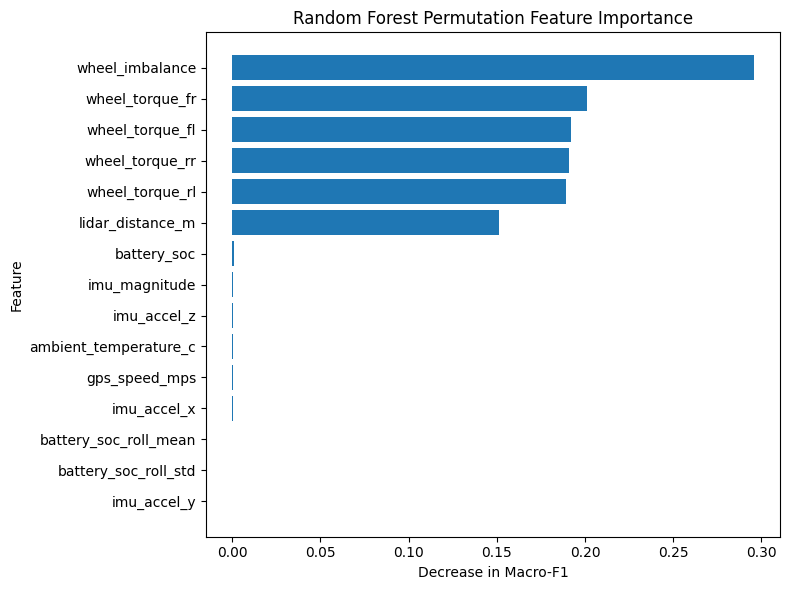

In [16]:
plot_perm = perm_importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(8, 6))

plt.barh(
    plot_perm["Feature"],
    plot_perm["Importance"]
)

plt.title("Random Forest Permutation Feature Importance")
plt.xlabel("Decrease in Macro-F1")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

**Interpretation:**  
Permutation importance confirms that wheel-related telemetry is the dominant source of predictive information. Unlike impurity-based importance, the engineered `wheel_imbalance` feature ranks first and produces the largest decrease in macro-F1 when shuffled. The four individual wheel torque measurements and LiDAR distance also remain highly important. The agreement between the two methods strengthens the evidence that wheel behavior is central to operational mode classification. Because `wheel_imbalance` is derived directly from the four wheel torque measurements, these predictors contain overlapping information, so their individual importance values should not be interpreted as fully independent effects.

## 4. FAULT vs PATROL Feature Analysis

The overall feature importance analysis explains four-class operational mode classification. To specifically identify the telemetry features that distinguish FAULT from normal PATROL operation, a separate binary Random Forest model is evaluated using only FAULT and PATROL observations.

In [17]:
fault_patrol_mask = y.isin(["FAULT", "PATROL"])

X_fp = X.loc[fault_patrol_mask].copy()
y_fp = y.loc[fault_patrol_mask].copy()

print("FAULT vs PATROL dataset shape:", X_fp.shape)

display(
    y_fp.value_counts()
)

FAULT vs PATROL dataset shape: (135926, 15)


PATROL    126960
FAULT       8966
Name: operational_mode, dtype: int64

### FAULT vs PATROL Train/Test Split

The binary dataset is divided using the same 80/20 stratified strategy to preserve the imbalance between FAULT and PATROL observations.

In [18]:
X_fp_train, X_fp_test, y_fp_train, y_fp_test = train_test_split(
    X_fp,
    y_fp,
    test_size=0.20,
    stratify=y_fp,
    random_state=RANDOM_SEED
)

fp_train_medians = X_fp_train.median()

X_fp_train = X_fp_train.fillna(fp_train_medians)
X_fp_test = X_fp_test.fillna(fp_train_medians)

print("Training set:", X_fp_train.shape)
print("Test set:", X_fp_test.shape)

print("\nTraining class distribution:")
print(y_fp_train.value_counts())

Training set: (108740, 15)
Test set: (27186, 15)

Training class distribution:
PATROL    101567
FAULT       7173
Name: operational_mode, dtype: int64


### Binary Random Forest Model

A Random Forest classifier is trained specifically to distinguish FAULT from PATROL using the same telemetry feature set as the multiclass model.

In [19]:
rf_fp = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

rf_fp.fit(X_fp_train, y_fp_train)

fp_pred = rf_fp.predict(X_fp_test)

fp_accuracy = rf_fp.score(
    X_fp_test,
    y_fp_test
)

fp_f1 = f1_score(
    y_fp_test,
    fp_pred,
    pos_label="FAULT"
)

print(f"FAULT vs PATROL Accuracy: {fp_accuracy:.4f}")
print(f"FAULT F1-score: {fp_f1:.4f}")

FAULT vs PATROL Accuracy: 0.9827
FAULT F1-score: 0.8593


### FAULT vs PATROL Permutation Importance

Permutation importance is calculated on the held-out binary test set using FAULT F1-score as the evaluation metric. This identifies which features are most important specifically for detecting FAULT relative to PATROL.

In [22]:
fault_f1_scorer = make_scorer(
    f1_score,
    pos_label="FAULT"
)

fp_perm_result = permutation_importance(
    rf_fp,
    X_fp_test,
    y_fp_test,
    scoring=fault_f1_scorer,
    n_repeats=5,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

fp_perm_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": fp_perm_result.importances_mean,
    "Std": fp_perm_result.importances_std
})

fp_perm_importance = fp_perm_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(fp_perm_importance)

,Feature,Importance,Std
0,wheel_imbalance,0.296976,0.001355
1,wheel_torque_fl,0.263729,0.001141
2,wheel_torque_fr,0.263609,0.002125
3,wheel_torque_rr,0.240734,0.001285
4,wheel_torque_rl,0.200579,0.001530
5,lidar_distance_m,0.142143,0.001568
6,battery_soc_roll_mean,0.001954,0.000608
7,imu_magnitude,0.001646,0.000530
8,battery_soc_roll_std,0.001389,0.000793
9,imu_accel_z,0.000994,0.000971


### FAULT vs PATROL Feature Importance Ranking

The ranking shows which telemetry features cause the largest decrease in FAULT detection performance when their information is disrupted.

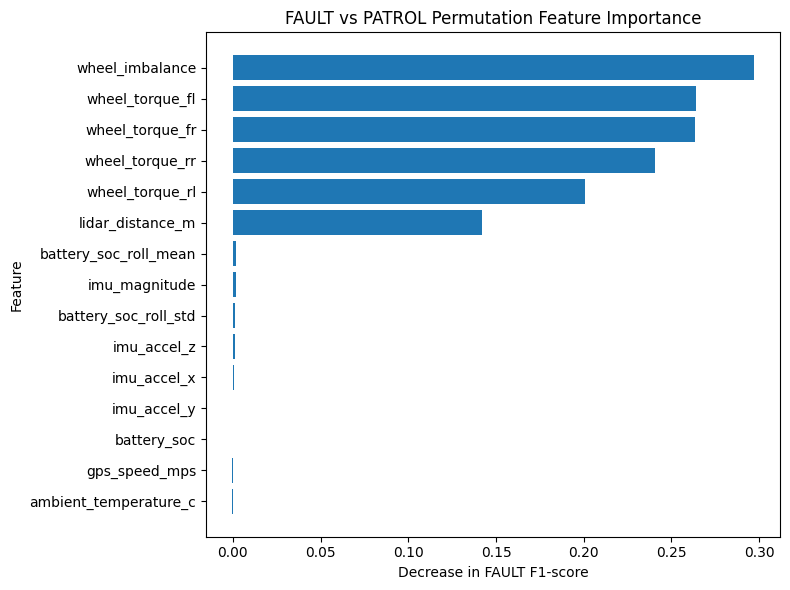

In [23]:
plot_fp = fp_perm_importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(8, 6))

plt.barh(
    plot_fp["Feature"],
    plot_fp["Importance"]
)

plt.title("FAULT vs PATROL Permutation Feature Importance")
plt.xlabel("Decrease in FAULT F1-score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

**Interpretation:**  
`wheel_imbalance` is the strongest feature for distinguishing FAULT from PATROL. Shuffling this feature causes the largest decrease in FAULT F1-score, followed by the four individual wheel torque measurements and LiDAR distance. In contrast, battery, IMU, GPS-derived speed, and ambient temperature contribute relatively little to this specific binary classification task.

Operationally, this result is plausible because an abnormal difference in torque across the Rover's wheels may indicate uneven loading, traction problems, drivetrain issues, or other mechanical behavior associated with a fault state. For fleet monitoring, wheel imbalance may therefore be a useful signal for identifying observations that warrant closer inspection. Because the dataset is synthetic, however, this relationship should be treated as a result of the simulated telemetry patterns rather than evidence of real-world Rover failure behavior.

## 5. Feature Importance Summary

Both feature importance methods identify wheel-related telemetry as the primary source of predictive information for operational mode classification.

Impurity-based importance ranks the four individual wheel torque measurements most highly, while permutation importance identifies the engineered `wheel_imbalance` feature as the most influential predictor. The difference reflects the complementary nature of the two methods: impurity importance measures how features contribute to decision-tree splits, whereas permutation importance measures how much held-out predictive performance decreases when a feature is disrupted.

The FAULT vs PATROL analysis provides a more targeted result. `wheel_imbalance` produces the largest decrease in FAULT F1-score when permuted, making it the strongest feature for distinguishing FAULT from PATROL in the synthetic dataset. Individual wheel torque measurements and LiDAR distance also contribute substantially.

The result demonstrates the value of feature engineering: combining four wheel torque measurements into a single imbalance score captures information about the relationship among the wheels that is particularly useful for fault discrimination.

For Rover fleet monitoring, wheel imbalance could serve as a useful signal for identifying observations that may require closer inspection. However, because the telemetry is synthetic, these findings reflect the simulated data-generating assumptions and would require validation using real operational data.